# Revert to P5 — Verification

Verifying that the **revert to P5** build produces correct results by comparing against:
- **GPU P5** (Persistent Tip State) — previous known-good GPU baseline
- **CPU backends**: OMP_48, OMP_10, VANILA

Models: AA/LG and DNA/GTR (unrooted)
100 taxa, 1M sites, 10 trees, 10 runs each

**Focus: likelihood correctness verification + opt_time consistency**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

REVERT_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_14_revert_to_p5')
P5_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_persistent_tip_state')
BASELINE_DIR = Path('/Users/u7826985/Projects/Nvidia/results/2026_03_13_branch_length_estimation')
SAVE_DIR = Path('.')

## 1. Parse All Log Files

In [2]:
def parse_log(filepath):
    try:
        with open(filepath, 'r') as f:
            text = f.read()
    except Exception:
        return None
    result = {}
    m = re.search(r'Total wall-clock time used:\s+([\d.]+)\s+sec', text)
    if m: result['walltime'] = float(m.group(1))
    m = re.search(r'Total CPU time used:\s+([\d.]+)\s+sec', text)
    if m: result['cputime'] = float(m.group(1))
    m = re.search(r'BEST SCORE FOUND\s*:\s*([\-\d.]+)', text)
    if m: result['log_likelihood'] = float(m.group(1))
    m = re.search(r'Total tree length:\s+([\d.]+)', text)
    if m: result['tree_length'] = float(m.group(1))
    m = re.search(r'Parameters optimization took \d+ rounds \(([\d.]+) sec\)', text)
    if m: result['opt_time'] = float(m.group(1))
    m = re.search(r'Parameters optimization took (\d+) rounds', text)
    if m: result['opt_rounds'] = int(m.group(1))
    m = re.search(r'Initial log-likelihood:.*?\(took\s+([\d.]+)\s+wall-clock sec\)', text)
    if m: result['first_eval_sec'] = float(m.group(1))
    return result if 'walltime' in result else None

def extract_run_number(filename):
    matches = re.findall(r'_run(\d+)_', filename)
    return int(matches[-1]) if matches else None

def classify_backend(filename):
    if 'OPENACC' in filename: return 'OPENACC'
    elif 'VANILA' in filename: return 'VANILA'
    elif 'OMP_48' in filename: return 'OMP_48'
    elif 'OMP_10' in filename: return 'OMP_10'
    return 'UNKNOWN'

def parse_results_dir(base_dir, backend_override=None, skip_profile=True):
    rows = []
    for data_type in ['AA', 'DNA']:
        for tree_type in ['rooted', 'unrooted']:
            type_dir = base_dir / data_type / tree_type
            if not type_dir.exists(): continue
            for model_dir in sorted(type_dir.iterdir()):
                if not model_dir.is_dir(): continue
                model = model_dir.name
                for tree_dir in sorted(model_dir.iterdir()):
                    if not tree_dir.is_dir(): continue
                    tree = tree_dir.name
                    for logfile in tree_dir.glob('*.log'):
                        fname = logfile.name
                        if skip_profile and 'profile' in fname.lower(): continue
                        backend = backend_override if backend_override else classify_backend(fname)
                        run_num = extract_run_number(fname)
                        metrics = parse_log(logfile)
                        if metrics:
                            rows.append({'data_type': data_type, 'tree_type': tree_type,
                                        'model': model, 'tree': tree, 'backend': backend,
                                        'run': run_num, 'filename': fname, **metrics})
    return rows

In [3]:
# Parse revert-to-P5 results
rows_revert = parse_results_dir(REVERT_DIR, backend_override='GPU_REVERT')
df_revert = pd.DataFrame(rows_revert)
print(f'Revert-to-P5: {len(df_revert)} entries')
print(df_revert.groupby(['data_type', 'backend']).size())

# Parse previous P5 (persistent tip state) — known-good baseline
rows_p5 = parse_results_dir(P5_DIR, backend_override='GPU_P5')
df_p5 = pd.DataFrame(rows_p5)
print(f'\nGPU P5 (baseline): {len(df_p5)} entries')

# Parse CPU baselines
rows_base = parse_results_dir(BASELINE_DIR)
df_base = pd.DataFrame(rows_base)
df_base = df_base[
    (df_base['tree_type'] == 'unrooted') &
    (((df_base['data_type'] == 'AA') & (df_base['model'] == 'LG')) |
     ((df_base['data_type'] == 'DNA') & (df_base['model'] == 'GTR')))
].copy()
df_cpu = df_base[df_base['backend'].isin(['VANILA', 'OMP_10', 'OMP_48'])].copy()
print(f'CPU baselines: {len(df_cpu)} entries')

# Combine
df = pd.concat([df_cpu, df_p5, df_revert], ignore_index=True)
df['overhead'] = df['walltime'] - df['opt_time']
df.to_csv(SAVE_DIR / 'results_all.csv', index=False)

print(f'\nCombined: {len(df)} entries')
print(df.groupby(['data_type', 'backend']).size().unstack(fill_value=0))

Revert-to-P5: 174 entries
data_type  backend   
AA         GPU_REVERT    95
DNA        GPU_REVERT    79
dtype: int64



GPU P5 (baseline): 179 entries


CPU baselines: 460 entries

Combined: 813 entries
backend    GPU_P5  GPU_REVERT  OMP_10  OMP_48  VANILA
data_type                                            
AA             99          95     100     100      20
DNA            80          79     100     100      40


## 2. Summary Statistics

In [4]:
summary = df.groupby(['data_type', 'model', 'backend']).agg(
    walltime_mean=('walltime', 'mean'),
    walltime_median=('walltime', 'median'),
    walltime_std=('walltime', 'std'),
    opt_time_mean=('opt_time', 'mean'),
    opt_time_median=('opt_time', 'median'),
    opt_time_std=('opt_time', 'std'),
    overhead_median=('overhead', 'median'),
    logl_mean=('log_likelihood', 'mean'),
    logl_std=('log_likelihood', 'std'),
    tree_length_mean=('tree_length', 'mean'),
    n_runs=('walltime', 'count')
).round(3)
summary.to_csv(SAVE_DIR / 'results_summary.csv')
summary

walltime_mean  walltime_median  walltime_std  \
data_type model backend                                                    
AA        LG    GPU_P5             17.671           18.286         1.312   
                GPU_REVERT         17.727           18.346         1.342   
                OMP_10             40.597           38.558         9.580   
                OMP_48             15.457           15.020         2.398   
                VANILA            251.787          250.290        33.784   
DNA       GTR   GPU_P5             25.050           23.621         3.414   
                GPU_REVERT         25.315           23.767         3.647   
                OMP_10             38.111           34.237        14.922   
                OMP_48             16.185           15.054         4.098   
                VANILA            133.017          121.995        22.931   

                            opt_time_mean  opt_time_median  opt_time_std  \
data_type model backend                                                    
AA        LG    GPU_P5             14.799           15.397         1.313   
                GPU_REVERT         14.798           15.420         1.337   
                OMP_10             39.260           37.316         9.464   
                OMP_48             14.026           13.586         2.357   
                VANILA            248.778          247.279        33.832   
DNA       GTR   GPU_P5             22.236           20.808         3.404   
                GPU_REVERT         22.183           20.836         3.340   
                OMP_10             36.906           33.174        14.858   
                OMP_48             15.061           13.606         4.082   
                VANILA            130.275          119.261        22.909   

                            overhead_median     logl_mean     logl_std  \
data_type model backend                                                  
AA        LG    GPU_P5                2.864 -8.632411e+07  2618006.962   
                GPU_REVERT            2.908 -8.630769e+07  2671866.291   
                OMP_10                1.276 -8.632801e+07  2605043.269   
                OMP_48                1.387 -8.632801e+07  2605043.269   
                VANILA                2.988 -8.970307e+07   822470.828   
DNA       GTR   GPU_P5                2.800 -6.655753e+07  1944873.717   
                GPU_REVERT            2.865 -6.654517e+07  1954139.964   
                OMP_10                1.079 -6.743701e+07  2633938.757   
                OMP_48                1.096 -6.743701e+07  2633938.757   
                VANILA                2.686 -6.653339e+07  1607473.986   

                            tree_length_mean  n_runs  
data_type model backend                               
AA        LG    GPU_P5                19.352      99  
                GPU_REVERT            19.358      95  
                OMP_10                19.351     100  
                OMP_48                19.351     100  
                VANILA                20.130      20  
DNA       GTR   GPU_P5                19.490      80  
                GPU_REVERT            19.487      79  
                OMP_10                19.912     100  
                OMP_48                19.912     100  
                VANILA                19.648      40

## 3. Likelihood Comparison (Critical Correctness Check)

In [5]:
# Per-tree, per-backend likelihood
logl_detail = df.groupby(['data_type', 'model', 'tree', 'backend']).agg(
    logl_mean=('log_likelihood', 'mean'),
    logl_std=('log_likelihood', 'std'),
    tree_length_mean=('tree_length', 'mean'),
    n=('log_likelihood', 'count')
).round(6).reset_index()
logl_detail.to_csv(SAVE_DIR / 'likelihood_per_tree_backend.csv', index=False)

logl_pivot = logl_detail.pivot_table(index=['data_type', 'model', 'tree'],
                                      columns='backend', values='logl_mean').reset_index()
print('Log-likelihood per tree per backend:')
display(logl_pivot.round(3))

Log-likelihood per tree per backend:


backend,data_type,model,tree,GPU_P5,GPU_REVERT,OMP_10,OMP_48,VANILA
0,AA,LG,tree_1,-8.890142e+07,-8.890142e+07,-8.890142e+07,-8.890142e+07,-8.890142e+07
1,AA,LG,tree_10,-8.671423e+07,-8.671423e+07,-8.671423e+07,-8.671423e+07,NaN
2,AA,LG,tree_2,-9.050471e+07,-9.050471e+07,-9.050471e+07,-9.050471e+07,-9.050471e+07
3,AA,LG,tree_3,-8.735700e+07,-8.735700e+07,-8.735700e+07,-8.735700e+07,NaN
4,AA,LG,tree_4,-8.771263e+07,-8.771263e+07,-8.771263e+07,-8.771263e+07,NaN
5,AA,LG,tree_5,-8.638277e+07,-8.638277e+07,-8.638277e+07,-8.638277e+07,NaN
6,AA,LG,tree_6,-8.430150e+07,-8.430150e+07,-8.430150e+07,-8.430150e+07,NaN
7,AA,LG,tree_7,-8.713416e+07,-8.713416e+07,-8.713416e+07,-8.713416e+07,NaN
8,AA,LG,tree_8,-8.193152e+07,-8.193152e+07,-8.193152e+07,-8.193152e+07,NaN
9,AA,LG,tree_9,-8.234019e+07,-8.234019e+07,-8.234019e+07,-8.234019e+07,NaN


In [6]:
# Likelihood differences: GPU_REVERT vs every other backend
diff_cols = []
for b in ['VANILA', 'OMP_10', 'OMP_48', 'GPU_P5']:
    if b in logl_pivot.columns and 'GPU_REVERT' in logl_pivot.columns:
        col = f'REVERT_minus_{b}'
        logl_pivot[col] = (logl_pivot['GPU_REVERT'] - logl_pivot[b]).round(6)
        diff_cols.append(col)

print('Likelihood differences (GPU_REVERT - other backend):')
print('0.0 = identical, NaN = tree not present in that backend')
display(logl_pivot[['data_type', 'model', 'tree'] + diff_cols])
logl_pivot.to_csv(SAVE_DIR / 'likelihood_comparison.csv', index=False)

# Summary of differences
print('\n=== Difference Summary ===')
for col in diff_cols:
    vals = logl_pivot[col].dropna()
    print(f'  {col}: min={vals.min():.6f}  max={vals.max():.6f}  '
          f'mean={vals.mean():.6f}  all_zero={all(vals == 0.0)}')

Likelihood differences (GPU_REVERT - other backend):
0.0 = identical, NaN = tree not present in that backend


backend,data_type,model,tree,REVERT_minus_VANILA,REVERT_minus_OMP_10,REVERT_minus_OMP_48,REVERT_minus_GPU_P5
0,AA,LG,tree_1,0.0,0.0,0.0,0.0
1,AA,LG,tree_10,NaN,0.0,0.0,0.0
2,AA,LG,tree_2,0.0,0.0,0.0,0.0
3,AA,LG,tree_3,NaN,0.0,0.0,0.0
4,AA,LG,tree_4,NaN,0.0,0.0,0.0
5,AA,LG,tree_5,NaN,0.0,0.0,0.0
6,AA,LG,tree_6,NaN,0.0,0.0,0.0
7,AA,LG,tree_7,NaN,0.0,0.0,0.0
8,AA,LG,tree_8,NaN,0.0,0.0,0.0
9,AA,LG,tree_9,NaN,0.0,0.0,0.0



=== Difference Summary ===
  REVERT_minus_VANILA: min=0.000000  max=0.000000  mean=0.000000  all_zero=True
  REVERT_minus_OMP_10: min=0.000000  max=0.000000  mean=0.000000  all_zero=True
  REVERT_minus_OMP_48: min=0.000000  max=0.000000  mean=0.000000  all_zero=True
  REVERT_minus_GPU_P5: min=0.000000  max=0.000000  mean=0.000000  all_zero=True


In [7]:
# Overall range check: max log-likelihood difference across ALL backends per tree
logl_range = df.groupby(['data_type', 'model', 'tree']).agg(
    logl_min=('log_likelihood', 'min'),
    logl_max=('log_likelihood', 'max'),
    logl_range=('log_likelihood', lambda x: x.max() - x.min()),
    tl_min=('tree_length', 'min'),
    tl_max=('tree_length', 'max'),
    tl_range=('tree_length', lambda x: x.max() - x.min())
).reset_index()
logl_range.to_csv(SAVE_DIR / 'likelihood_range_check.csv', index=False)

logl_mismatch = logl_range[logl_range['logl_range'] > 0.01]
tl_mismatch = logl_range[logl_range['tl_range'] > 0.001]

print(f'Log-likelihood mismatches (range > 0.01): {len(logl_mismatch)}')
if len(logl_mismatch) > 0:
    display(logl_mismatch)
else:
    print('  \u2705 All backends produce identical log-likelihoods.')

print(f'\nTree length mismatches (range > 0.001): {len(tl_mismatch)}')
if len(tl_mismatch) > 0:
    display(tl_mismatch)
else:
    print('  \u2705 All backends produce identical tree lengths.')

Log-likelihood mismatches (range > 0.01): 0
  ✅ All backends produce identical log-likelihoods.

Tree length mismatches (range > 0.001): 0
  ✅ All backends produce identical tree lengths.


## 4. Optimization Time Comparison

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/1466247084.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/1466247084.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/1466247084.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/14662

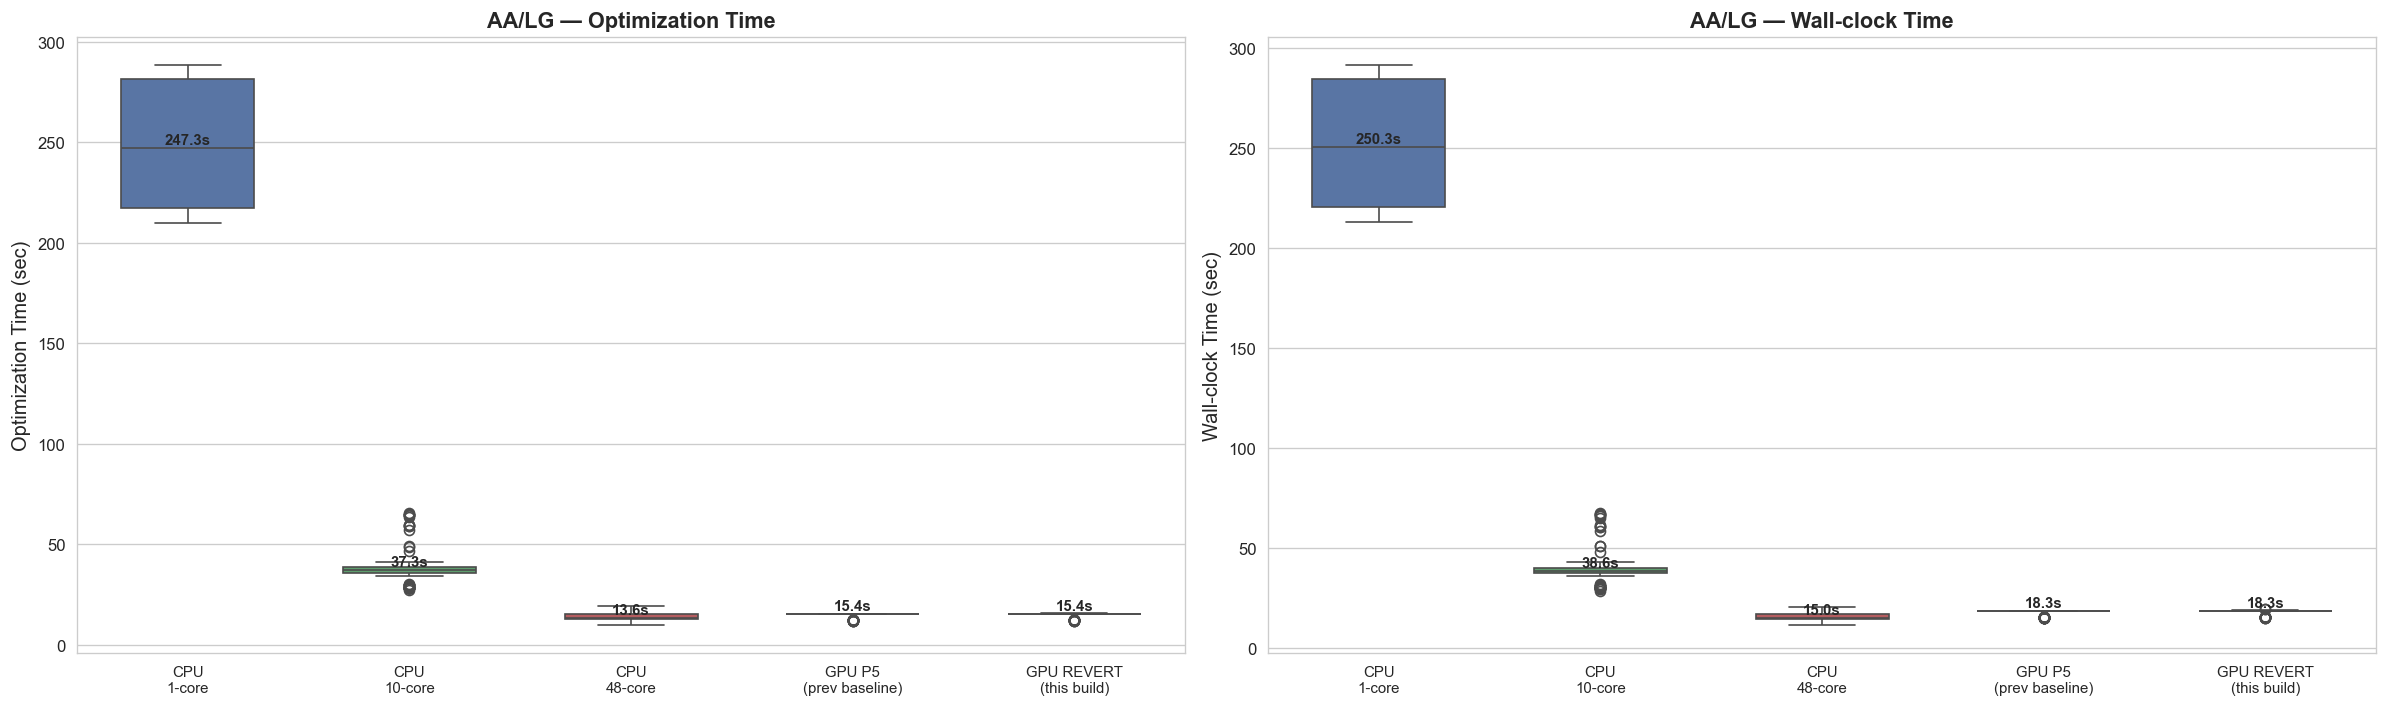

Saved: opt_wall_comparison_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/1466247084.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/1466247084.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/1466247084.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/14662

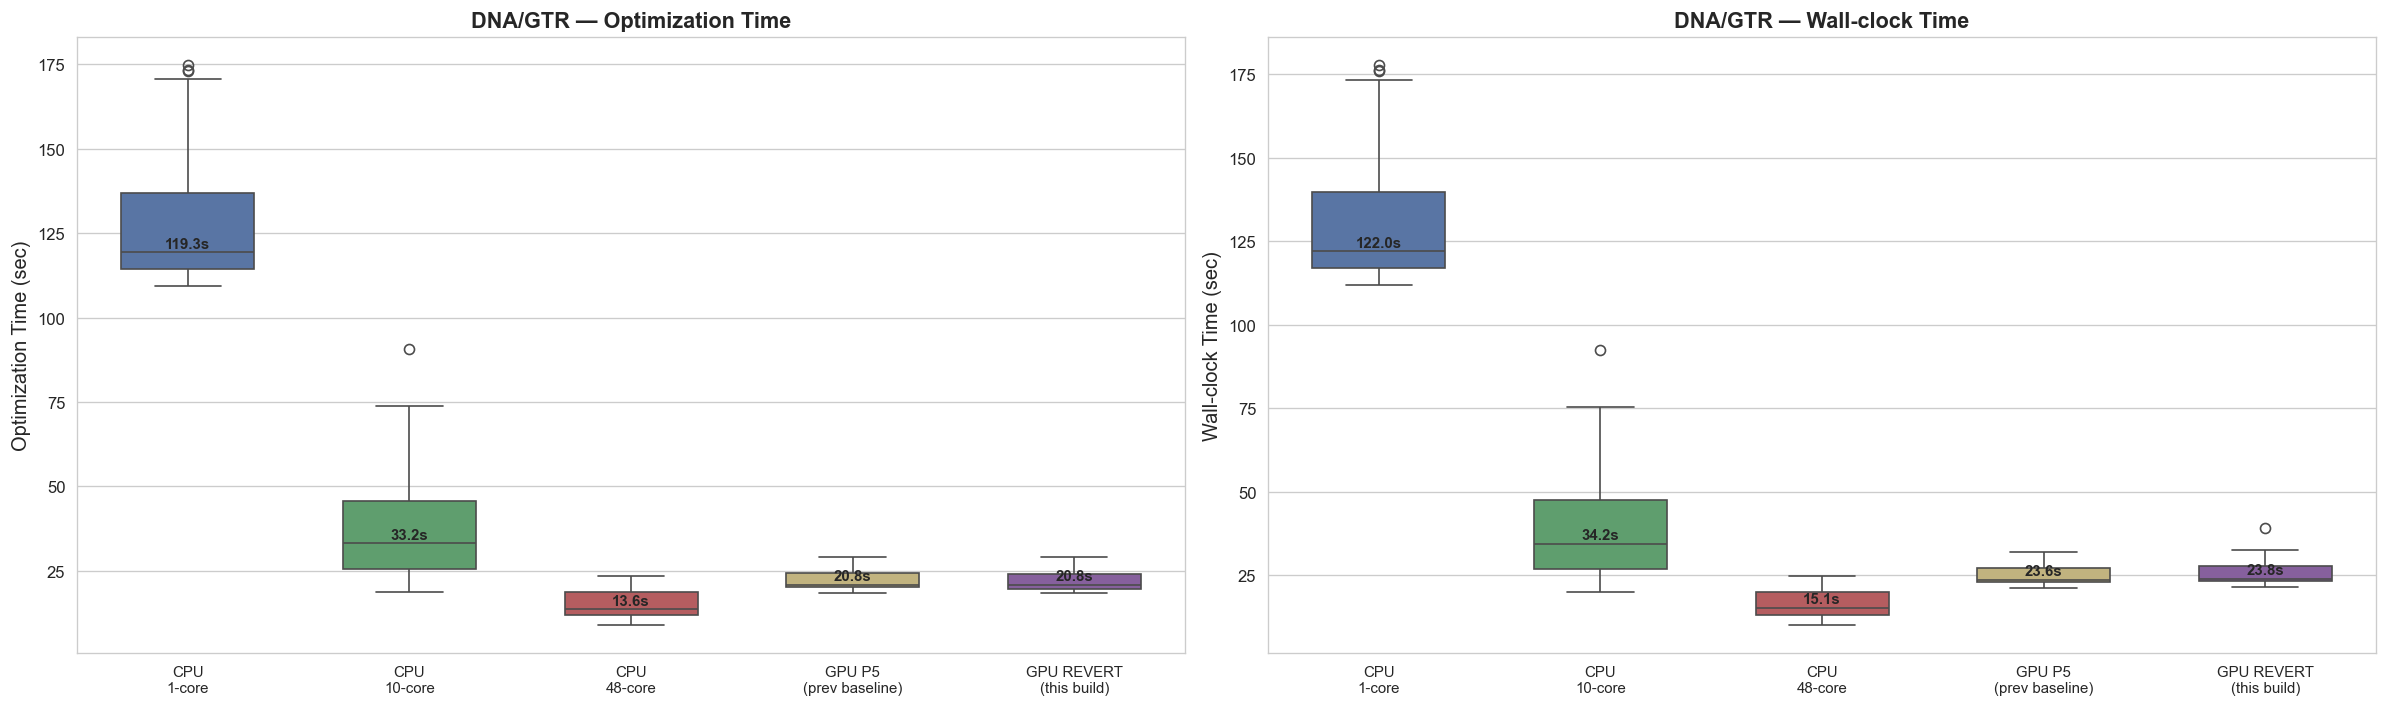

Saved: opt_wall_comparison_DNA_GTR.png


In [8]:
backend_order = ['VANILA', 'OMP_10', 'OMP_48', 'GPU_P5', 'GPU_REVERT']
backend_colors = {
    'VANILA': '#4C72B0', 'OMP_10': '#55A868', 'OMP_48': '#C44E52',
    'GPU_P5': '#CCB974', 'GPU_REVERT': '#8856a7'
}
backend_labels = {
    'VANILA': 'CPU\n1-core', 'OMP_10': 'CPU\n10-core', 'OMP_48': 'CPU\n48-core',
    'GPU_P5': 'GPU P5\n(prev baseline)', 'GPU_REVERT': 'GPU REVERT\n(this build)'
}

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model)]
    present = [b for b in backend_order if b in subset['backend'].unique()]
    palette = [backend_colors[b] for b in present]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 6))
    
    # Left: Optimization time boxplot
    sns.boxplot(data=subset, x='backend', y='opt_time',
               order=present, palette=palette, ax=ax1, width=0.6)
    ax1.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)
    ax1.set_ylabel('Optimization Time (sec)', fontsize=12)
    ax1.set_xlabel('')
    ax1.set_title(f'{data_type}/{model} — Optimization Time', fontsize=13, fontweight='bold')
    medians = subset.groupby('backend')['opt_time'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax1.text(i, medians[b] + 0.5, f'{medians[b]:.1f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    # Right: Walltime boxplot
    sns.boxplot(data=subset, x='backend', y='walltime',
               order=present, palette=palette, ax=ax2, width=0.6)
    ax2.set_xticklabels([backend_labels.get(b, b) for b in present], fontsize=9)
    ax2.set_ylabel('Wall-clock Time (sec)', fontsize=12)
    ax2.set_xlabel('')
    ax2.set_title(f'{data_type}/{model} — Wall-clock Time', fontsize=13, fontweight='bold')
    medians_wt = subset.groupby('backend')['walltime'].median()
    for i, b in enumerate(present):
        if b in medians_wt.index:
            ax2.text(i, medians_wt[b] + 0.5, f'{medians_wt[b]:.1f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    fname = f'opt_wall_comparison_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 5. GPU P5 vs GPU REVERT — Direct Comparison

/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/3575224281.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/3575224281.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(p_labels, fontsize=11)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/3575224281.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/3575224281.py:37: UserWarning: set_tick

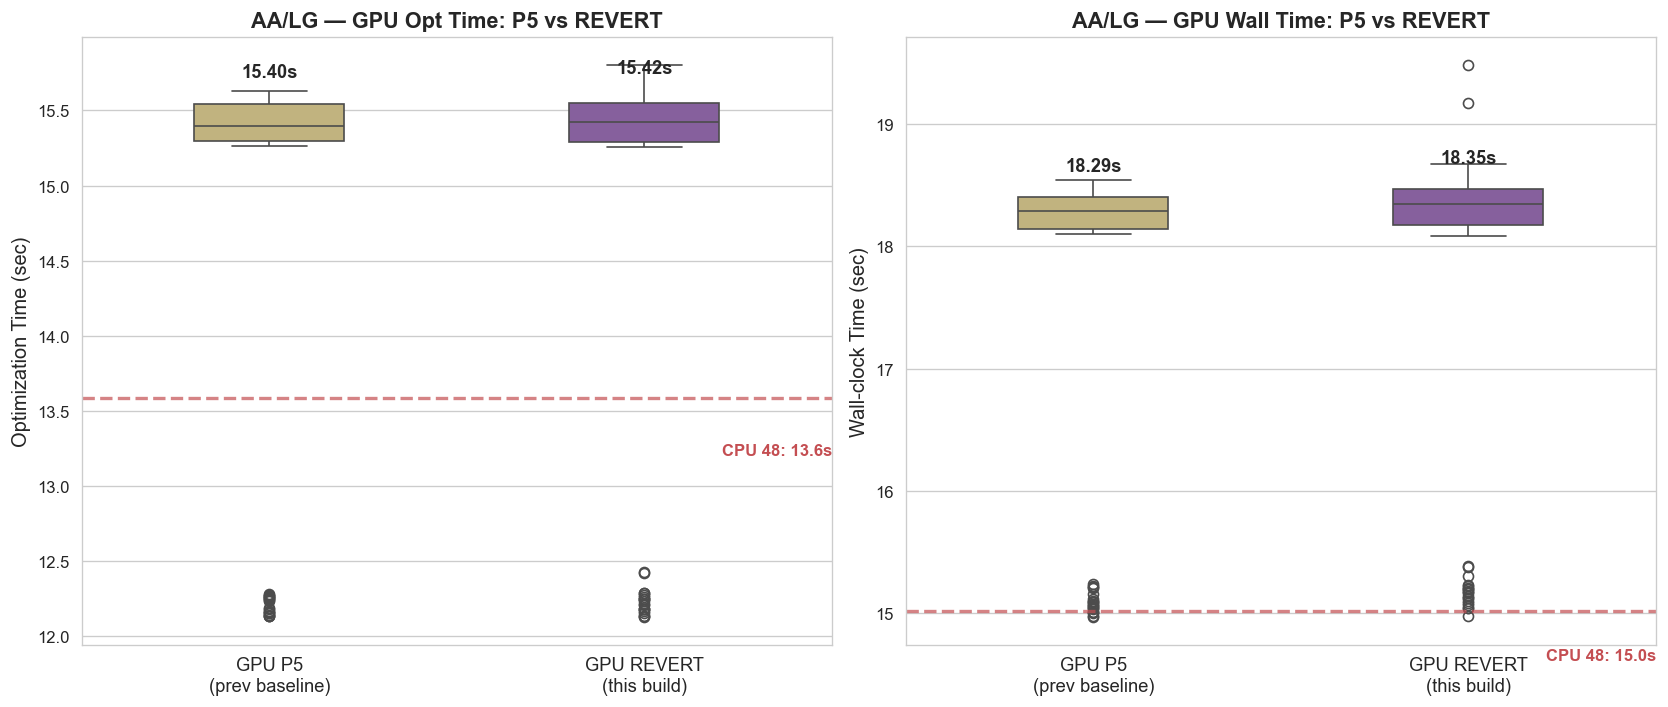

Saved: gpu_p5_vs_revert_AA_LG.png


/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/3575224281.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='opt_time',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/3575224281.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(p_labels, fontsize=11)
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/3575224281.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x='backend', y='walltime',
/var/folders/tp/72vhl3f90v5ch7bm64vsrlgj_rwbf2/T/ipykernel_84446/3575224281.py:37: UserWarning: set_tick

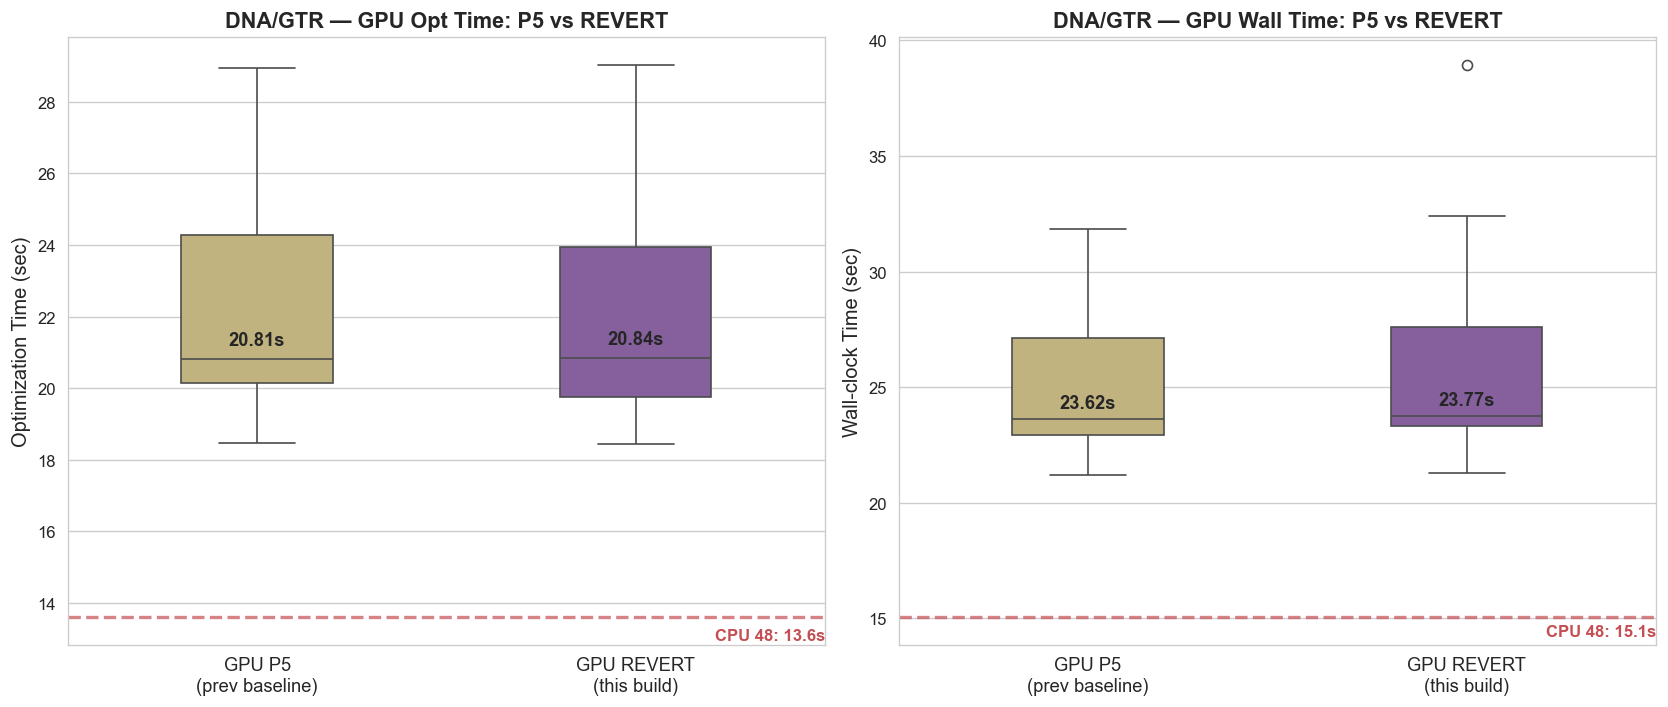

Saved: gpu_p5_vs_revert_DNA_GTR.png


In [9]:
gpu_order = ['GPU_P5', 'GPU_REVERT']
gpu_labels = ['GPU P5\n(prev baseline)', 'GPU REVERT\n(this build)']
gpu_colors = ['#CCB974', '#8856a7']

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model) &
               df['backend'].isin(gpu_order)]
    present = [b for b in gpu_order if b in subset['backend'].unique()]
    p_colors = [gpu_colors[gpu_order.index(b)] for b in present]
    p_labels = [gpu_labels[gpu_order.index(b)] for b in present]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Left: opt_time
    sns.boxplot(data=subset, x='backend', y='opt_time',
               order=present, palette=p_colors, ax=ax1, width=0.4)
    ax1.set_xticklabels(p_labels, fontsize=11)
    ax1.set_ylabel('Optimization Time (sec)', fontsize=12)
    ax1.set_xlabel('')
    ax1.set_title(f'{data_type}/{model} — GPU Opt Time: P5 vs REVERT', fontsize=13, fontweight='bold')
    medians = subset.groupby('backend')['opt_time'].median()
    for i, b in enumerate(present):
        if b in medians.index:
            ax1.text(i, medians[b] + 0.3, f'{medians[b]:.2f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=11)
    # CPU 48-core reference
    cpu48_opt = df[(df['data_type'] == data_type) & (df['model'] == model) & 
                   (df['backend'] == 'OMP_48')]['opt_time'].median()
    if not np.isnan(cpu48_opt):
        ax1.axhline(y=cpu48_opt, color='#C44E52', linestyle='--', alpha=0.7, linewidth=2)
        ax1.text(len(present) - 0.5, cpu48_opt - 0.3, f'CPU 48: {cpu48_opt:.1f}s',
               fontsize=10, color='#C44E52', fontweight='bold', ha='right', va='top')
    
    # Right: walltime
    sns.boxplot(data=subset, x='backend', y='walltime',
               order=present, palette=p_colors, ax=ax2, width=0.4)
    ax2.set_xticklabels(p_labels, fontsize=11)
    ax2.set_ylabel('Wall-clock Time (sec)', fontsize=12)
    ax2.set_xlabel('')
    ax2.set_title(f'{data_type}/{model} — GPU Wall Time: P5 vs REVERT', fontsize=13, fontweight='bold')
    medians_wt = subset.groupby('backend')['walltime'].median()
    for i, b in enumerate(present):
        if b in medians_wt.index:
            ax2.text(i, medians_wt[b] + 0.3, f'{medians_wt[b]:.2f}s',
                   ha='center', va='bottom', fontweight='bold', fontsize=11)
    cpu48_wt = df[(df['data_type'] == data_type) & (df['model'] == model) & 
                  (df['backend'] == 'OMP_48')]['walltime'].median()
    if not np.isnan(cpu48_wt):
        ax2.axhline(y=cpu48_wt, color='#C44E52', linestyle='--', alpha=0.7, linewidth=2)
        ax2.text(len(present) - 0.5, cpu48_wt - 0.3, f'CPU 48: {cpu48_wt:.1f}s',
               fontsize=10, color='#C44E52', fontweight='bold', ha='right', va='top')
    
    plt.tight_layout()
    fname = f'gpu_p5_vs_revert_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 6. Per-Tree Opt Time

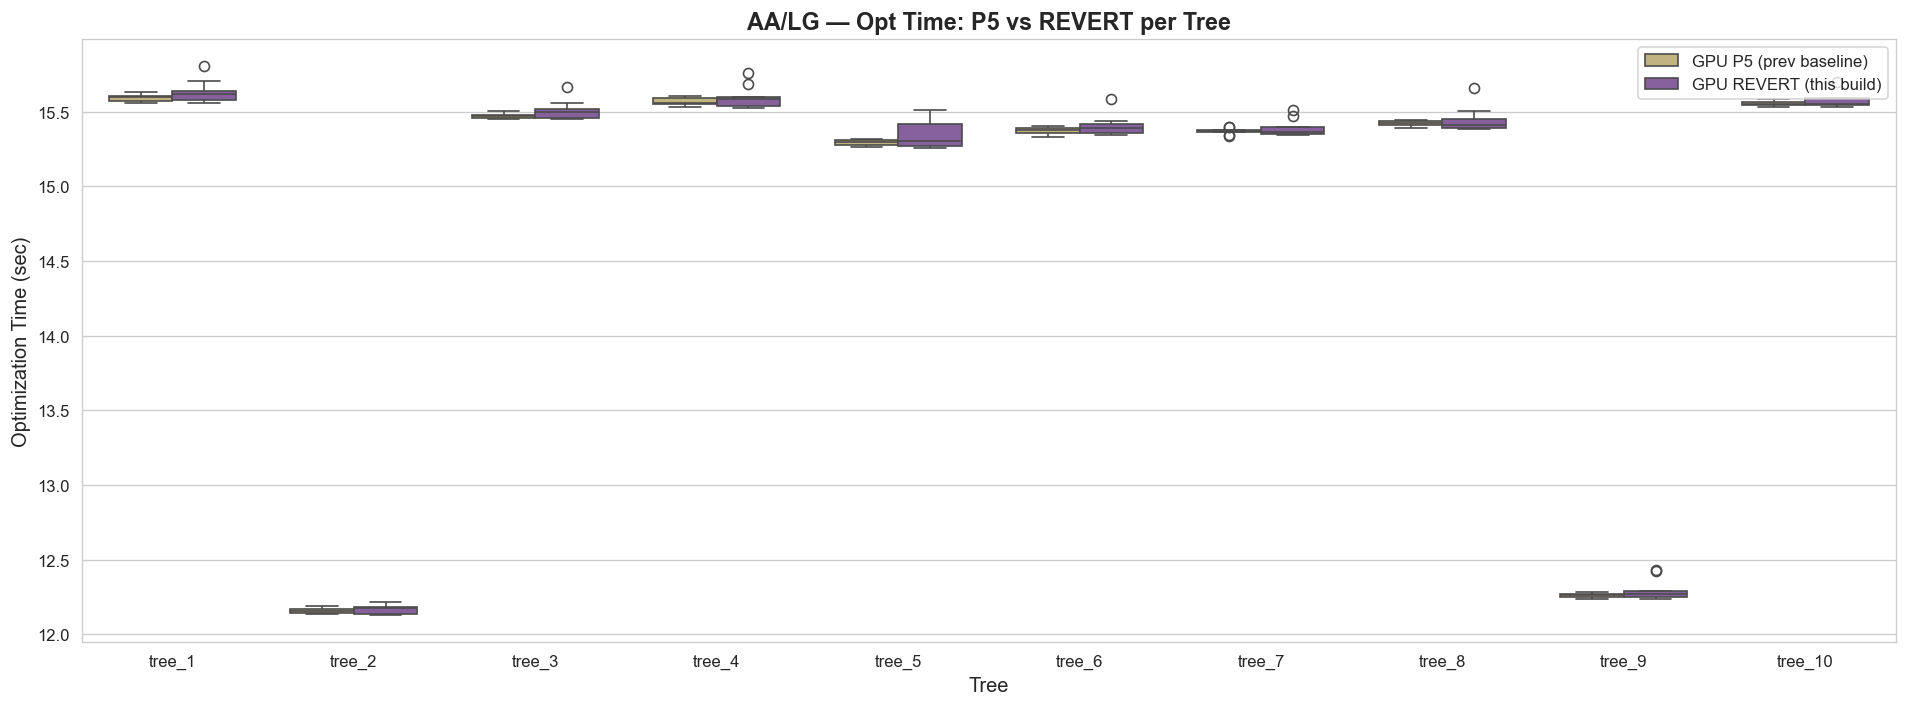

Saved: opt_per_tree_AA_LG.png


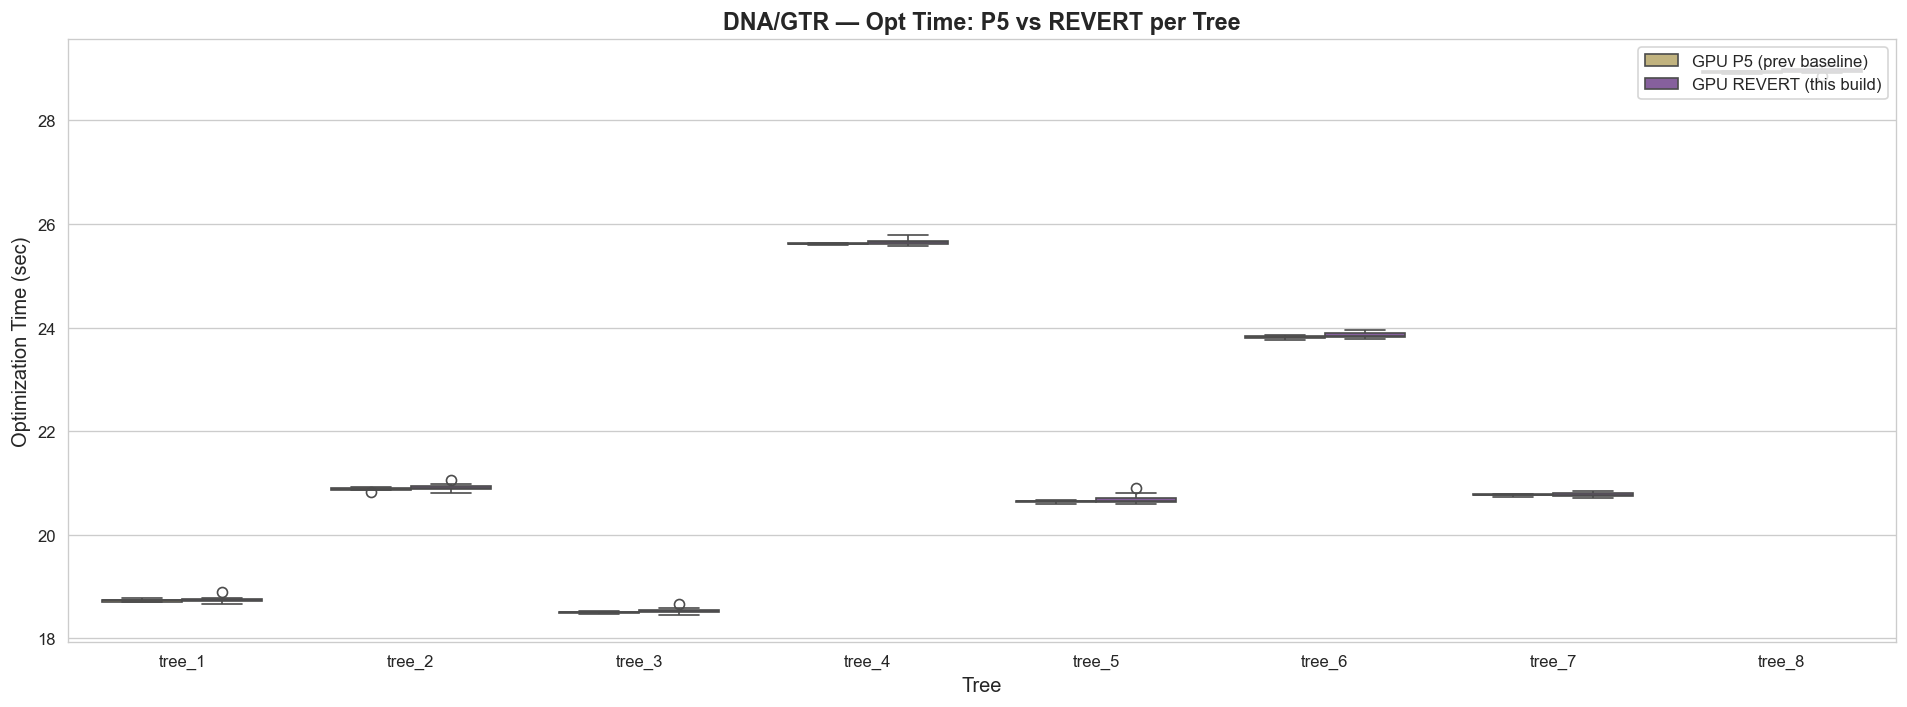

Saved: opt_per_tree_DNA_GTR.png


In [10]:
for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    subset = df[(df['data_type'] == data_type) & (df['model'] == model) &
               df['backend'].isin(['GPU_P5', 'GPU_REVERT'])]
    if subset.empty: continue
    trees = sorted(subset['tree'].unique(), key=lambda x: int(x.split('_')[1]))
    
    fig, ax = plt.subplots(figsize=(16, 6))
    sns.boxplot(data=subset, x='tree', y='opt_time', hue='backend',
               order=trees, hue_order=['GPU_P5', 'GPU_REVERT'],
               palette=['#CCB974', '#8856a7'],
               ax=ax, width=0.7)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, ['GPU P5 (prev baseline)', 'GPU REVERT (this build)'],
             fontsize=10, loc='upper right')
    ax.set_xlabel('Tree', fontsize=12)
    ax.set_ylabel('Optimization Time (sec)', fontsize=12)
    ax.set_title(f'{data_type}/{model} — Opt Time: P5 vs REVERT per Tree',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    fname = f'opt_per_tree_{data_type}_{model}.png'
    plt.savefig(SAVE_DIR / fname, bbox_inches='tight')
    plt.show()
    print(f'Saved: {fname}')

## 7. Time Breakdown

In [11]:
print('=== Time Breakdown (median values) ===')
for dt in ['AA', 'DNA']:
    print(f'\n--- {dt} ---')
    for b in backend_order:
        sub = df[(df['data_type'] == dt) & (df['backend'] == b)]
        if sub.empty: continue
        print(f"  {b:14s}  walltime={sub['walltime'].median():7.2f}s  "
              f"opt_time={sub['opt_time'].median():7.2f}s  "
              f"overhead={sub['overhead'].median():5.2f}s  "
              f"opt%={sub['opt_time'].median()/sub['walltime'].median()*100:5.1f}%  "
              f"(n={len(sub)})")

=== Time Breakdown (median values) ===

--- AA ---
  VANILA          walltime= 250.29s  opt_time= 247.28s  overhead= 2.99s  opt%= 98.8%  (n=20)
  OMP_10          walltime=  38.56s  opt_time=  37.32s  overhead= 1.28s  opt%= 96.8%  (n=100)
  OMP_48          walltime=  15.02s  opt_time=  13.59s  overhead= 1.39s  opt%= 90.5%  (n=100)
  GPU_P5          walltime=  18.29s  opt_time=  15.40s  overhead= 2.86s  opt%= 84.2%  (n=99)
  GPU_REVERT      walltime=  18.35s  opt_time=  15.42s  overhead= 2.91s  opt%= 84.1%  (n=95)

--- DNA ---
  VANILA          walltime= 122.00s  opt_time= 119.26s  overhead= 2.69s  opt%= 97.8%  (n=40)
  OMP_10          walltime=  34.24s  opt_time=  33.17s  overhead= 1.08s  opt%= 96.9%  (n=100)
  OMP_48          walltime=  15.05s  opt_time=  13.61s  overhead= 1.10s  opt%= 90.4%  (n=100)
  GPU_P5          walltime=  23.62s  opt_time=  20.81s  overhead= 2.80s  opt%= 88.1%  (n=80)
  GPU_REVERT      walltime=  23.77s  opt_time=  20.84s  overhead= 2.87s  opt%= 87.7%  (n=79)


## 8. Final Summary

In [12]:
final = df.groupby(['data_type', 'model', 'backend']).agg(
    walltime_median=('walltime', 'median'),
    opt_time_median=('opt_time', 'median'),
    overhead_median=('overhead', 'median'),
    mean_logl=('log_likelihood', 'mean'),
    n_runs=('walltime', 'count')
).round(2).reset_index()

# Speedup columns
for ref_name, ref_backend in [('vs_cpu48', 'OMP_48'), ('vs_P5', 'GPU_P5')]:
    ref = final[final['backend'] == ref_backend][['data_type', 'model', 'opt_time_median']].rename(
        columns={'opt_time_median': 'ref'})
    final = final.merge(ref, on=['data_type', 'model'], how='left')
    final[f'opt_speedup_{ref_name}'] = (final['ref'] / final['opt_time_median']).round(2)
    final.drop(columns='ref', inplace=True)

final.to_csv(SAVE_DIR / 'final_summary.csv', index=False)

print('=== Final Summary ===')
display(final)

=== Final Summary ===


,data_type,model,backend,walltime_median,opt_time_median,overhead_median,mean_logl,n_runs,opt_speedup_vs_cpu48,opt_speedup_vs_P5
0,AA,LG,GPU_P5,18.29,15.40,2.86,-86324112.64,99,0.88,1.00
1,AA,LG,GPU_REVERT,18.35,15.42,2.91,-86307686.71,95,0.88,1.00
2,AA,LG,OMP_10,38.56,37.32,1.28,-86328013.80,100,0.36,0.41
3,AA,LG,OMP_48,15.02,13.59,1.39,-86328013.80,100,1.00,1.13
4,AA,LG,VANILA,250.29,247.28,2.99,-89703067.78,20,0.05,0.06
5,DNA,GTR,GPU_P5,23.62,20.81,2.80,-66557528.13,80,0.65,1.00
6,DNA,GTR,GPU_REVERT,23.77,20.84,2.87,-66545174.85,79,0.65,1.00
7,DNA,GTR,OMP_10,34.24,33.17,1.08,-67437010.89,100,0.41,0.63
8,DNA,GTR,OMP_48,15.05,13.61,1.10,-67437010.89,100,1.00,1.53
9,DNA,GTR,VANILA,122.00,119.26,2.69,-66533394.68,40,0.11,0.17


## 9. Conclusions

In [13]:
print('=' * 80)
print('CONCLUSIONS — Revert to P5 Verification')
print('=' * 80)

for data_type, model in [('AA', 'LG'), ('DNA', 'GTR')]:
    sub = df[(df['data_type'] == data_type) & (df['model'] == model)]
    gpu_rev = sub[sub['backend'] == 'GPU_REVERT']
    gpu_p5 = sub[sub['backend'] == 'GPU_P5']
    cpu48 = sub[sub['backend'] == 'OMP_48']
    
    print(f'\n--- {data_type}/{model} ---')
    
    if not gpu_rev.empty:
        rev_opt = gpu_rev['opt_time'].median()
        rev_wt = gpu_rev['walltime'].median()
        print(f'  GPU REVERT: opt={rev_opt:.2f}s  wall={rev_wt:.2f}s')
    
    if not gpu_p5.empty:
        p5_opt = gpu_p5['opt_time'].median()
        p5_wt = gpu_p5['walltime'].median()
        print(f'  GPU P5:     opt={p5_opt:.2f}s  wall={p5_wt:.2f}s')
        if not gpu_rev.empty:
            opt_change = (p5_opt - rev_opt) / p5_opt * 100
            print(f'  REVERT vs P5: opt_time {opt_change:+.1f}% (should be ~0%)')
    
    if not cpu48.empty:
        c48_opt = cpu48['opt_time'].median()
        print(f'  CPU 48:     opt={c48_opt:.2f}s')
        if not gpu_rev.empty:
            ratio = rev_opt / c48_opt
            print(f'  REVERT vs CPU48: {ratio:.2f}x ({"slower" if ratio > 1 else "faster"})')

# Likelihood check
print(f'\n{"=" * 80}')
print('LIKELIHOOD VERIFICATION:')
range_check = df.groupby(['data_type', 'model', 'tree']).agg(
    logl_range=('log_likelihood', lambda x: x.max() - x.min())
).reset_index()
max_range = range_check['logl_range'].max()
print(f'  Max log-likelihood range across any tree: {max_range}')
if max_range < 0.01:
    print('  \u2705 ALL BACKENDS PRODUCE IDENTICAL LOG-LIKELIHOODS.')
    print('  \u2705 REVERT TO P5 IS CORRECT.')
else:
    print('  \u274c WARNING: Some trees have likelihood mismatches!')
    display(range_check[range_check['logl_range'] > 0.01])

CONCLUSIONS — Revert to P5 Verification

--- AA/LG ---
  GPU REVERT: opt=15.42s  wall=18.35s
  GPU P5:     opt=15.40s  wall=18.29s
  REVERT vs P5: opt_time -0.1% (should be ~0%)
  CPU 48:     opt=13.59s
  REVERT vs CPU48: 1.14x (slower)

--- DNA/GTR ---
  GPU REVERT: opt=20.84s  wall=23.77s
  GPU P5:     opt=20.81s  wall=23.62s
  REVERT vs P5: opt_time -0.1% (should be ~0%)
  CPU 48:     opt=13.61s
  REVERT vs CPU48: 1.53x (slower)

LIKELIHOOD VERIFICATION:
  Max log-likelihood range across any tree: 0.0
  ✅ ALL BACKENDS PRODUCE IDENTICAL LOG-LIKELIHOODS.
  ✅ REVERT TO P5 IS CORRECT.
